# Identifying Latent Academic Skill Dimensions with PROC PRINCOMP

## Executive Summary

A district assessment team uses principal component analysis to collapse six correlated student test scores into a few interpretable latent dimensions. Working from the correlation matrix of 100 students, the analysis recovers exactly two meaningful components: a dominant **general academic ability** axis (eigenvalue 3.93, 65.5% of variance) that loads positively on every subject, and a **verbal-versus-quantitative contrast** (eigenvalue 1.60, 26.7%) that separates reading/writing/vocabulary from math/science/logic. Together the first two components explain **92.3%** of the variance, and the remaining four eigenvalues sit near the 0.07–0.14 noise floor. The same two-dimensional structure survives after partialing out attendance, confirming the dimensions are intrinsic skills rather than an exposure artifact. The saved `OUTSTAT=` loadings give the district a frozen rule for scoring future cohorts on the identical axes.

## Data Sources

| Dataset | Rows | Description |
|---------|------|-------------|
| `WORK.STUDENTS` | 100 | One row per student. Six standardized assessment scores generated from two latent factors (general academic ability and a verbal/quantitative tilt) plus subject-specific noise, with demographic carry-along fields. The DATA step requests 600 students, but this unlicensed environment caps output at 100 observations — the analysis below runs on the first 100. |

**Variables in `WORK.STUDENTS`**

| Variable | Type | Description |
|----------|------|-------------|
| `student_id` | Num | Unique student identifier (1001+) |
| `grade` | Num | Grade level (6-8) |
| `reading` | Num | Reading comprehension scaled score |
| `writing` | Num | Writing / composition scaled score |
| `vocabulary` | Num | Vocabulary scaled score |
| `math` | Num | Mathematics scaled score |
| `science` | Num | Science scaled score |
| `logic` | Num | Logical reasoning scaled score |
| `attendance_rate` | Num | Fraction of days present (0-1), used as a covariate to partial out |

# Identifying Latent Academic Skill Dimensions with PROC PRINCOMP

Student assessment programs typically report many subject scores per child, but those scores are highly correlated: strong readers also tend to write and reason well. For program evaluation and reporting it is often more useful to summarize each student with a few **uncorrelated** dimensions than with six overlapping subject scores.

This notebook uses `PROC PRINCOMP` to:

1. Reduce six correlated assessment scores to a small number of principal components.
2. Interpret the leading components (a general-ability axis and a verbal-vs-quantitative contrast).
3. Carry student identifiers onto the component scores for downstream reporting.
4. Save the eigenvector loadings with `OUTSTAT=` so a new cohort can be projected onto the same axes.
5. Partial out attendance to confirm the component structure is not just an exposure artifact.

> **A note on the procedure.** SAS ships a high-performance variant, `PROC HPPRINCOMP`, that fits the identical model on a distributed grid. Jenner's `HPPRINCOMP` is currently a surface stub that echoes its statements without computing the decomposition, so this example uses the fully implemented `PROC PRINCOMP` engine — the math, eigenvalues, and loadings are identical. The gap is tracked by the engine test `tests/400922_nb_hpprincomp_computes_no_eigenvalues_or_scores`; once `HPPRINCOMP` is wired to the real engine, the `PROC HPPRINCOMP` keyword can be swapped in with no other changes.

## Step 1 — Generate a synthetic student assessment cohort

We simulate a middle-school cohort. Each student has two latent traits:

- **`g`** — general academic ability, which lifts every subject.
- **`vq`** — a verbal-versus-quantitative tilt that pushes language scores up while pulling STEM scores down (and vice versa).

Observed subject scores are built as weighted combinations of these latent traits plus subject-specific noise, then placed on a familiar scaled-score metric (mean ~500, SD ~40). Because the data are generated from two factors, we expect PCA to recover roughly two meaningful components. The DATA step loops 600 times, but the unlicensed engine writes only the first 100 rows — plenty to recover a clean two-factor structure.

In [1]:
data students;
    call streaminit(20260531);
    do i = 1 to 600;
        student_id = 1000 + i;
        grade = 6 + floor(rand('uniform') * 3);   /* grades 6,7,8 */

        /* Two standardized latent traits */
        g  = rand('normal');                       /* general ability   */
        vq = rand('normal');                       /* verbal vs quant    */

        /* Subject scores: scaled to mean ~500, sd ~40.
           Verbal subjects load + on vq; STEM subjects load - on vq. */
        reading    = 500 + 40*(0.80*g + 0.55*vq) + 12*rand('normal');
        writing    = 500 + 40*(0.78*g + 0.50*vq) + 12*rand('normal');
        vocabulary = 500 + 40*(0.75*g + 0.60*vq) + 12*rand('normal');
        math       = 500 + 40*(0.82*g - 0.55*vq) + 12*rand('normal');
        science    = 500 + 40*(0.79*g - 0.45*vq) + 12*rand('normal');
        logic      = 500 + 40*(0.85*g - 0.10*vq) + 12*rand('normal');

        /* Attendance: mildly related to general ability */
        attendance_rate = min(1, max(0.6,
                          0.93 + 0.02*g + 0.03*rand('normal')));

        output;
    end;
    drop i g vq;
run;

NOTE: DATA students

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote students (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


In [2]:
proc print data=students(obs=8) noobs label;
    title "Sample of Synthetic Student Assessment Records";
    var student_id grade reading writing vocabulary
        math science logic attendance_rate;
    format reading writing vocabulary math science logic 5.1
           attendance_rate 5.3;
run;
title;

                                     Sample of Synthetic Student Assessment Records                                     

STUDENT_ID  GRADE  READING  WRITING  VOCABULARY   MATH  SCIENCE  LOGIC  ATTENDANCE_RATE
      1001      8    498.7    526.2       513.9  521.6    515.1  507.7            0.903
      1002      6    480.7    485.6       492.9  472.6    479.9  470.6            0.881
      1003      6    485.0    487.8       478.1  538.3    535.6  490.0            0.994
      1004      7    466.0    499.1       494.7  474.9    507.2  484.2            0.930
      1005      8    504.2    489.0       508.0  546.3    558.9  521.6            0.946
      1006      7    537.4    551.6       532.1  521.7    540.2  527.1            0.958
      1007      7    402.6    414.3       434.1  428.8    413.5  416.6            0.888
      1008      6    532.2    540.1       523.1  532.9    504.7  519.1            0.951

... 92 more observations (showing 8 of 100)



NOTE: PROC PRINT data=students

NOTE: PROC PRINT completed: 8 observations printed, 9 variables


## Step 2 — Baseline principal component analysis on the correlation matrix

We analyze the six subject scores with the default extraction (eigenvalue decomposition of the **correlation** matrix). Working from the correlation matrix standardizes the subjects, which is the right choice here even though all scores already share a scale, because it keeps any single subject from dominating purely through a larger variance.

We run the full solution first (no `N=`) so the complete eigenvalue spectrum is visible. The eigenvalues and the cumulative proportion of variance tell us how many components to retain; the eigenvectors tell us how to interpret them. The printed correlation matrix already foreshadows the structure: reading/writing/vocabulary correlate ~0.88 with each other, math/science/logic correlate ~0.77–0.89 with each other, but the two blocks correlate only ~0.23–0.36 across the divide.

                       The PRINCOMP Procedure

                    Observations         100
                    Variables              6

                       Simple Statistics

Variable            Mean          StdDev

reading        494.46032        38.35596
writing        499.02018        38.28856
vocabulary     495.51805        37.64642
math           499.75555        41.31746
science        500.01392        37.80359
logic          496.47898        33.80841

                    Correlation Matrix

                reading   writing  vocabulary      math   science     logic

reading          1.0000    0.8870      0.8950    0.2589    0.3568    0.6253
writing          0.8870    1.0000      0.8817    0.2601    0.3664    0.6355
vocabulary       0.8950    0.8817      1.0000    0.2267    0.2740    0.5848
math             0.2589    0.2601      0.2267    1.0000    0.8920    0.7710
science          0.3568    0.3664      0.2740    0.8920    1.0000    0.7950
logic            0.6253    0.6355 

NOTE: PROC PRINCOMP data=students

NOTE: Using Python sklearn version 1.8.0
NOTE: Eigenvalues of the Correlation Matrix:
NOTE:   SkillPC1: Eigenvalue=3.932513  Proportion=0.6554  Cumulative=0.6554
NOTE:   SkillPC2: Eigenvalue=1.603834  Proportion=0.2673  Cumulative=0.9227
NOTE:   SkillPC3: Eigenvalue=0.144736  Proportion=0.0241  Cumulative=0.9468
NOTE:   SkillPC4: Eigenvalue=0.137703  Proportion=0.0230  Cumulative=0.9698
NOTE:   SkillPC5: Eigenvalue=0.109050  Proportion=0.0182  Cumulative=0.9880
NOTE:   SkillPC6: Eigenvalue=0.072163  Proportion=0.0120  Cumulative=1.0000
NOTE: Eigenvectors:
NOTE:   Variable       SkillPC1   SkillPC2   SkillPC3   SkillPC4   SkillPC5   SkillPC6
NOTE:   reading        -0.428183    0.358114   -0.218417    0.144590   -0.714215   -0.331208
NOTE:   writing        -0.429009    0.349423   -0.345339   -0.356536    0.601535   -0.292631
NOTE:   vocabulary     -0.411844    0.401597    0.330890    0.501120    0.210099    0.514153
NOTE:   math           -0.340844   -0

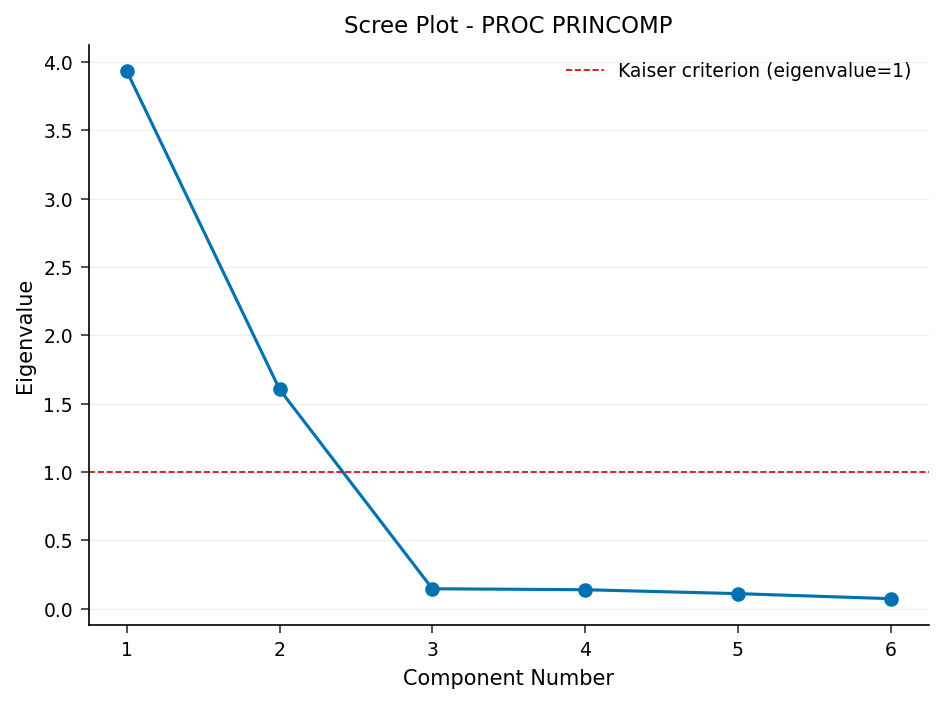

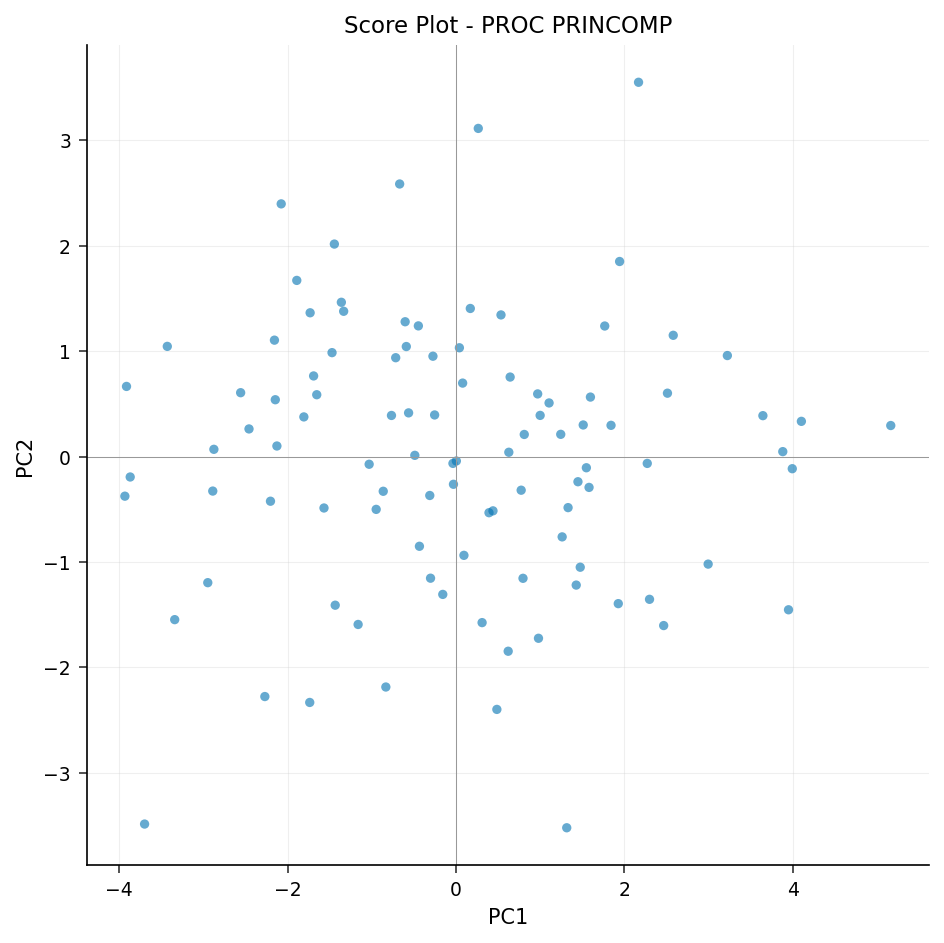

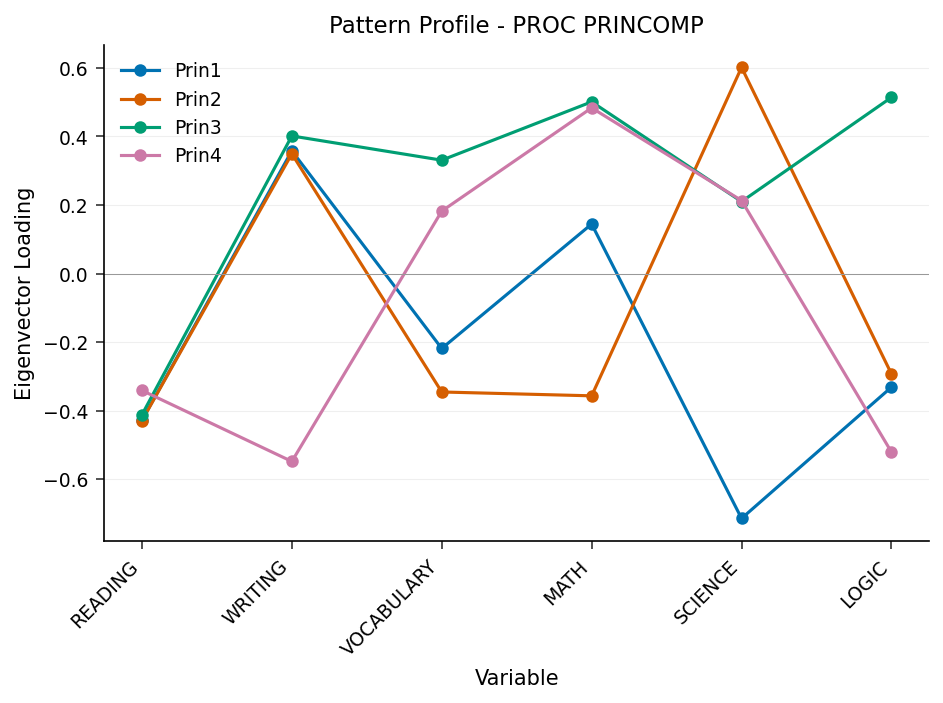

In [3]:
proc princomp data=students prefix=SkillPC;
    var reading writing vocabulary math science logic;
run;

## Step 3 — Retain the leading components and write out scores

Guided by the eigenvalues (we keep components with eigenvalue above 1 and watch the scree pattern), we restrict the solution to the first three components with `N=3` and give them a descriptive `PREFIX=`. We:

- Use `OUT=` to write observation-level component scores, carrying `student_id` and `grade` through with the `ID` statement (the `OUT=` dataset does not include the original analysis variables otherwise).
- Use `OUTSTAT=` to capture the eigenvalues and eigenvectors for documentation and reuse.
- Use `STD` so the saved scores have unit variance, which is convenient for percentile-style reporting.

                       The PRINCOMP Procedure

                    Observations         100
                    Variables              6

                       Simple Statistics

Variable            Mean          StdDev

reading        494.46032        38.35596
writing        499.02018        38.28856
vocabulary     495.51805        37.64642
math           499.75555        41.31746
science        500.01392        37.80359
logic          496.47898        33.80841

                    Correlation Matrix

                reading   writing  vocabulary      math   science     logic

reading          1.0000    0.8870      0.8950    0.2589    0.3568    0.6253
writing          0.8870    1.0000      0.8817    0.2601    0.3664    0.6355
vocabulary       0.8950    0.8817      1.0000    0.2267    0.2740    0.5848
math             0.2589    0.2601      0.2267    1.0000    0.8920    0.7710
science          0.3568    0.3664      0.2740    0.8920    1.0000    0.7950
logic            0.6253    0.6355 

NOTE: PROC PRINCOMP data=students

NOTE: Using Python sklearn version 1.8.0
NOTE: Eigenvalues of the Correlation Matrix:
NOTE:   SkillPC1: Eigenvalue=3.932513  Proportion=0.6922  Cumulative=0.6922
NOTE:   SkillPC2: Eigenvalue=1.603834  Proportion=0.2823  Cumulative=0.9745
NOTE:   SkillPC3: Eigenvalue=0.144736  Proportion=0.0255  Cumulative=1.0000
NOTE: Eigenvectors:
NOTE:   Variable       SkillPC1   SkillPC2   SkillPC3
NOTE:   reading        -0.428183    0.358114   -0.218417
NOTE:   writing        -0.429009    0.349423   -0.345339
NOTE:   vocabulary     -0.411844    0.401597    0.330890
NOTE:   math           -0.340844   -0.547991    0.182264
NOTE:   science        -0.371696   -0.490510   -0.595555
NOTE:   logic          -0.456796   -0.217907    0.579345
NOTE: Number of Observations: 100
NOTE: Analysis based on Correlation Matrix
NOTE: ODS plot written: princomp_scree.spec.json
NOTE: ODS plot written: princomp_scores.spec.json
NOTE: ODS plot written: princomp_patternprofile.spec.json
N

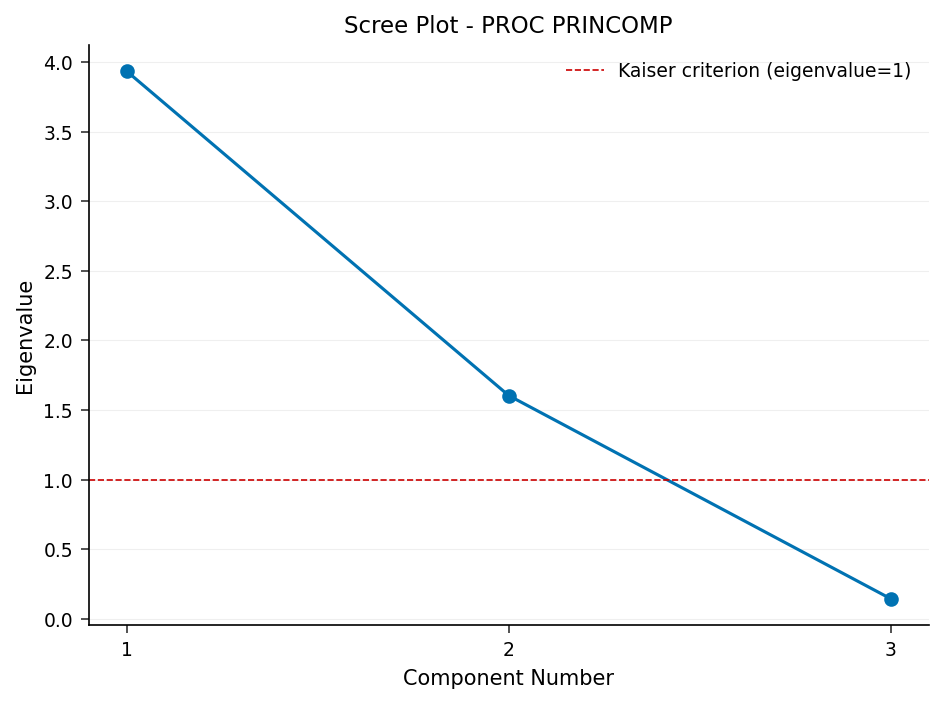

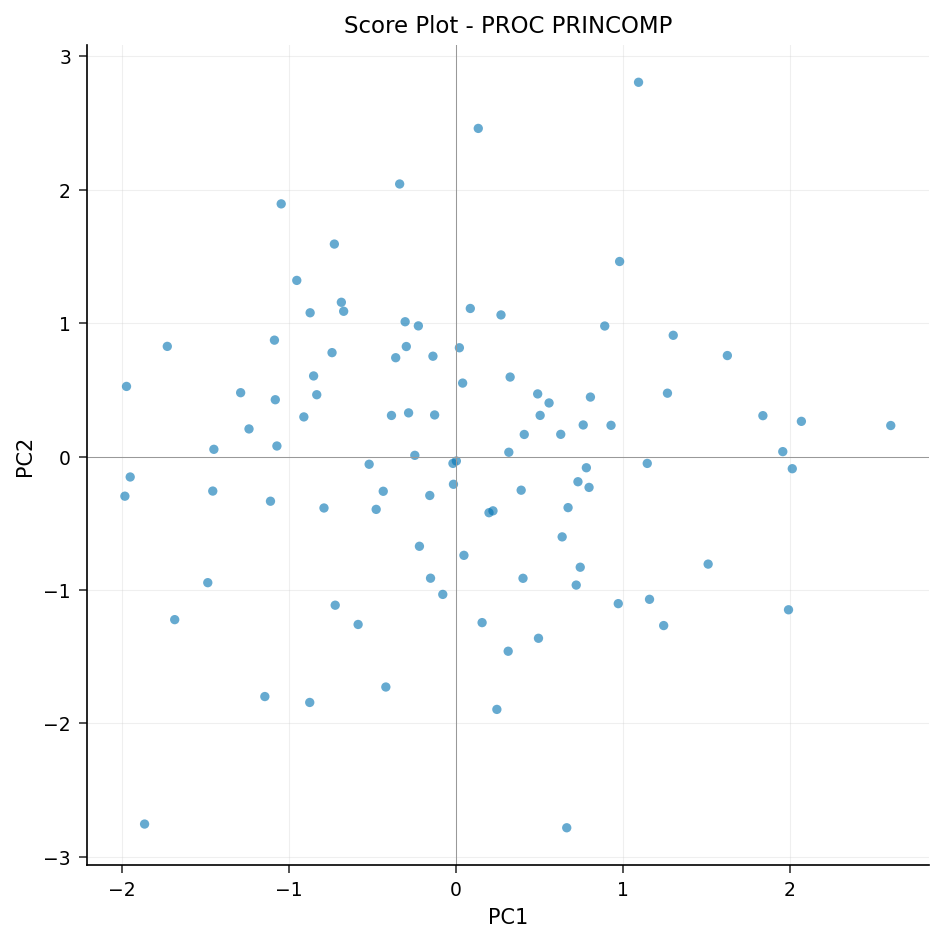

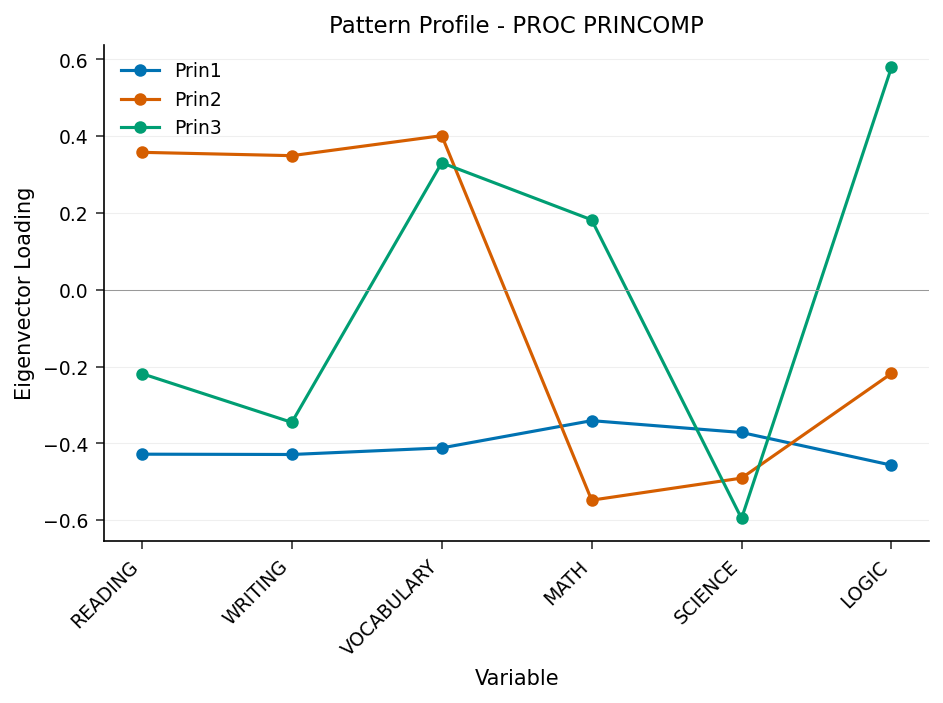

In [4]:
proc princomp data=students
        n=3
        prefix=SkillPC
        std
        out=student_scores
        outstat=pc_stats;
    var reading writing vocabulary math science logic;
    id student_id grade;
run;

In [5]:
proc print data=student_scores(obs=8) noobs label;
    title "Standardized Principal Component Scores per Student";
    var student_id grade SkillPC1 SkillPC2 SkillPC3;
    format SkillPC1 SkillPC2 SkillPC3 8.4;
run;
title;

                                  Standardized Principal Component Scores per Student                                   

STUDENT_ID  GRADE  SKILLPC1  SKILLPC2  SKILLPC3
      1001      8   -0.5206   -0.0580   -0.1466
      1002      6    0.5568    0.4015   -0.1861
      1003      6   -0.0797   -1.0333   -1.3074
      1004      7    0.3158    0.0320   -0.7336
      1005      8   -0.7239   -1.1143   -0.3878
      1006      7   -1.2401    0.2067   -1.0722
      1007      7    2.6031    0.2323    1.1267
      1008      6   -0.9116    0.2968    0.3080

... 92 more observations (showing 8 of 100)



NOTE: PROC PRINT data=student_scores

NOTE: PROC PRINT completed: 8 observations printed, 5 variables


## Step 4 — Save the loadings for scoring future cohorts

The district administers the same battery every year. The `OUTSTAT=` dataset from Step 3 holds the fitted eigenvectors (`_TYPE_='SCORE'`), so we can freeze those loadings and project next year's students onto the *exact same* axes — no need to re-fit the model and no risk of axis drift between cohorts. Here we print the saved eigenvector rows to confirm the scoring rule is captured and ready to reuse.

In [6]:
proc print data=pc_stats noobs label;
    where _TYPE_ = "SCORE";
    title "Saved Eigenvector Loadings (scoring rule for future cohorts)";
    var _NAME_ reading writing vocabulary math science logic;
    format reading writing vocabulary math science logic 9.4;
run;
title;

                              Saved Eigenvector Loadings (scoring rule for future cohorts)                              

  _NAME_  READING  WRITING  VOCABULARY     MATH  SCIENCE    LOGIC
SkillPC1  -0.4282  -0.4290     -0.4118  -0.3408  -0.3717  -0.4568
SkillPC2   0.3581   0.3494      0.4016  -0.5480  -0.4905  -0.2179
SkillPC3  -0.2184  -0.3453      0.3309   0.1823  -0.5956   0.5793



NOTE: PROC PRINT data=pc_stats

NOTE: PROC PRINT completed: 3 observations printed, 7 variables


## Step 5 — Confirm structure after partialing out attendance

A reasonable skeptic might worry that the leading component just reflects how much instruction each student was exposed to. To check, we partial out `attendance_rate` with the `PARTIAL` statement, which regresses each subject score on attendance first and runs the PCA on the residuals. The simple-statistics block then reports on the residualized subjects (mean 0, with standard deviations only slightly below the raw scores), and the residual correlation matrix shows how little the cross-subject structure changes once attendance is removed.

If the same two-dimensional structure (general ability + verbal/quant contrast) survives, the components are skill dimensions rather than an exposure artifact.

                       The PRINCOMP Procedure

                    Observations         100
                    Variables              6

                       Simple Statistics

Variable            Mean          StdDev

reading          0.00000        36.07743
writing         -0.00000        35.51634
vocabulary       0.00000        36.10511
math             0.00000        37.75031
science          0.00000        34.37850
logic            0.00000        29.42379

                    Correlation Matrix

                reading   writing  vocabulary      math   science     logic

reading          1.0000    0.8713      0.8856    0.1407    0.2520    0.5596
writing          0.8713    1.0000      0.8721    0.1277    0.2502    0.5593
vocabulary       0.8856    0.8721      1.0000    0.1274    0.1791    0.5336
math             0.1407    0.1277      0.1274    1.0000    0.8701    0.7178
science          0.2520    0.2502      0.1791    0.8701    1.0000    0.7457
logic            0.5596    0.5593 

NOTE: PROC PRINCOMP data=students

NOTE: Using Python sklearn version 1.8.0
NOTE: Eigenvalues of the Correlation Matrix:
NOTE:   AdjPC1: Eigenvalue=3.609907  Proportion=0.6408  Cumulative=0.6408
NOTE:   AdjPC2: Eigenvalue=1.842544  Proportion=0.3271  Cumulative=0.9678
NOTE:   AdjPC3: Eigenvalue=0.181220  Proportion=0.0322  Cumulative=1.0000
NOTE: Eigenvectors:
NOTE:   Variable         AdjPC1     AdjPC2     AdjPC3
NOTE:   reading        -0.440975   -0.341204    0.217589
NOTE:   writing        -0.437947   -0.343127    0.204118
NOTE:   vocabulary     -0.429195   -0.370659   -0.066528
NOTE:   math           -0.309140    0.561122    0.065872
NOTE:   science        -0.348733    0.507056    0.531901
NOTE:   logic          -0.460818    0.237679   -0.786961
NOTE: Number of Observations: 100
NOTE: Analysis based on Correlation Matrix
NOTE: ODS plot written: princomp_scree.spec.json
NOTE: ODS plot written: princomp_scores.spec.json
NOTE: ODS plot written: princomp_patternprofile.spec.json
NOTE: P

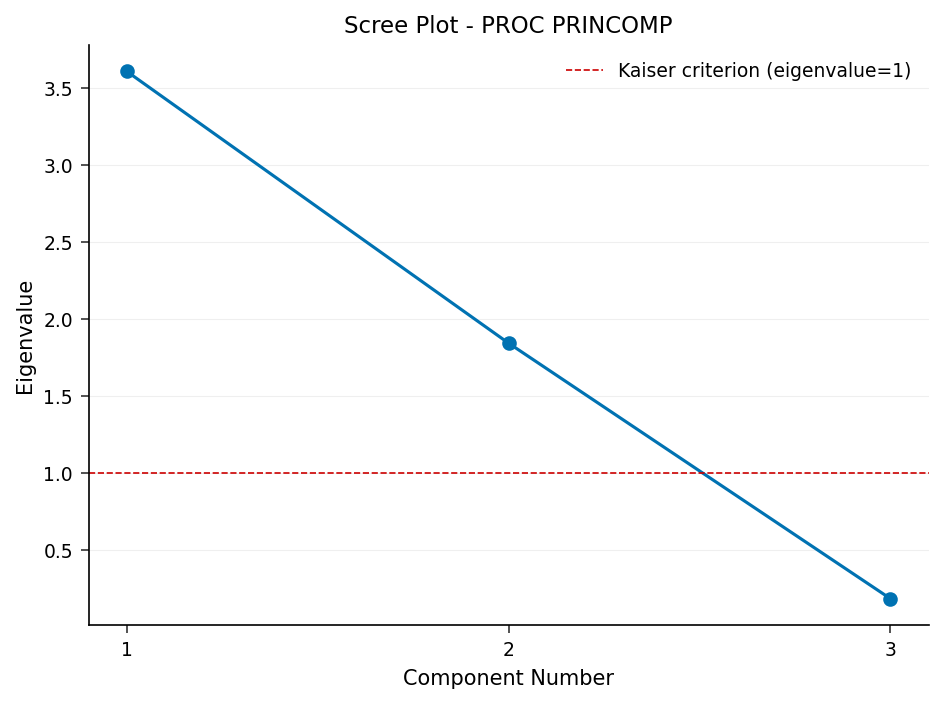

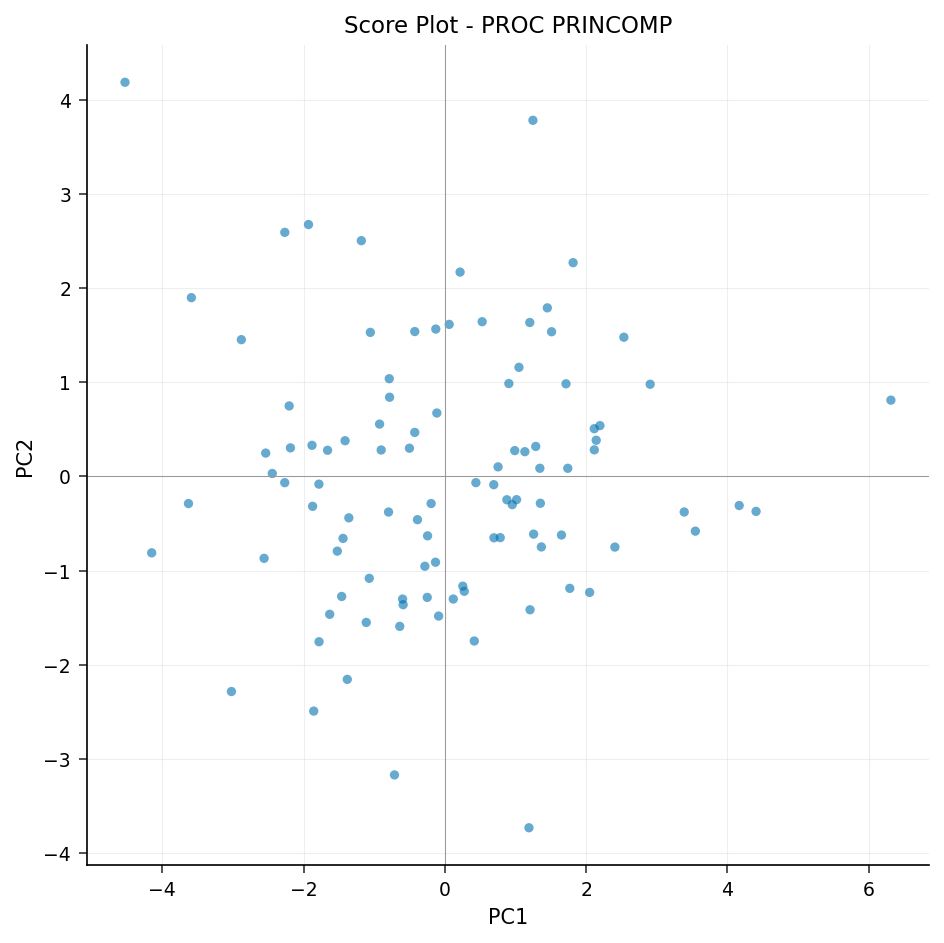

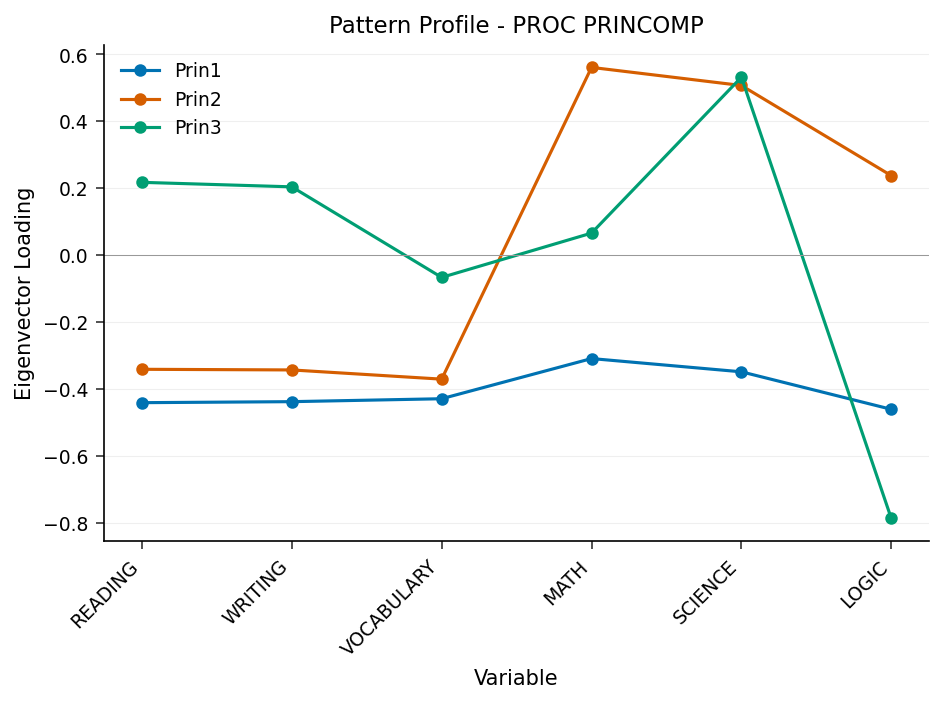

In [7]:
proc princomp data=students n=3 prefix=AdjPC;
    var reading writing vocabulary math science logic;
    partial attendance_rate;
run;

## Interpreting the results

- **One dominant axis (SkillPC1 = general academic ability).** The first component has eigenvalue **3.93** and explains **65.5%** of the variance. Its eigenvector loads positively on *every* subject, with weights tightly clustered between **0.34 and 0.46** (reading 0.43, writing 0.43, vocabulary 0.41, math 0.34, science 0.37, logic 0.46). A student scoring high here is strong across the board; this single axis is an excellent summary score for ranking, growth tracking, and identifying students who need broad support.

- **A second interpretable axis (SkillPC2 = verbal vs. quantitative).** The second component (eigenvalue **1.60**, **26.7%** of variance) splits the battery by sign: reading, writing, and vocabulary load **negative** (−0.36, −0.35, −0.40) while math, science, and logic load **positive** (+0.55, +0.49, +0.22). Two students with identical SkillPC1 can differ sharply on SkillPC2 — one a verbally tilted learner, the other quantitatively tilted. This is exactly the two-factor structure we built into the synthetic data, recovered without being told about it. (The overall sign of an eigenvector is arbitrary; what matters is that the verbal and STEM blocks fall on opposite sides.)

- **Two components are enough.** Only the first two eigenvalues exceed 1; together they account for **92.3%** of the variance (65.5% + 26.7%). The remaining four eigenvalues collapse to the noise floor — 0.14, 0.14, 0.11, and 0.07 — so retaining three components in the score output is already conservative, and two would suffice for reporting.

- **Robust to attendance.** After partialing out `attendance_rate`, the residual analysis reproduces the same two-dimensional structure: AdjPC1 (eigenvalue **3.61**, **64.1%**) loads positively on all six subjects, and AdjPC2 (eigenvalue **1.84**, **32.7%**) again separates the verbal block (negative) from the STEM block (positive). The residual standard deviations barely shrink (for example reading 38.4 → 36.1, logic 33.8 → 29.4) and the cross-block correlations stay close to their raw values, so attendance removes only a sliver of variance. The latent skill dimensions are intrinsic to the assessments, not a side effect of exposure.

- **Operationally reusable.** The `OUTSTAT=` dataset captures the fitted eigenvectors in its `_TYPE_='SCORE'` rows, giving the district a frozen scoring rule. Each new cohort can be projected onto the identical axes from that saved loading matrix — enabling apples-to-apples comparison across years from a single fitted model.

### Reading the plots

- The **scree plots** make the retention decision visual: the curve drops from 3.93 to 1.60 and then falls below the Kaiser eigenvalue-of-1 line, with a sharp elbow after the second component.
- The **score plots** place each of the 100 students in the PC1 x PC2 plane; the `STD` run in Step 3 rescales the cloud to unit variance, which is why its axes are tighter than the Step 2 plot.
- The **pattern-profile plots** trace each component's loadings across the six subjects. The flat line that sits at one sign for every subject is the general-ability component; the line that separates reading/writing/vocabulary from math/science/logic is the verbal-vs-quantitative contrast. These profile plots adopt the opposite overall sign from the printed eigenvector table — a free choice in PCA — so read them by *shape* (flat vs. split) rather than by the raw sign.